# Introduction

In this notebook we are analyzing the market of data-field freelancing so we can find<br>
useful or informative insights. In this analysis we are looking at UpWork & Guru data-field<br>
freelancers, in terms of skills, earnings etc ...<br>
So let's look at we have

> **NOTE**: Data-field refers to tech jobs that work mainly with data which are:
> - Data analysts 
> - Data engineers
> - Data scientests
> - Machine learning developers

Things we are analysing in this notebook:
- [Q1](#q1). Earnings distribution
- [Q2](#q2). Common skills
- [Q3](#q3). Hour rate change
- [Q4](#q4). Average job cost

# Setting up

In [2]:
import os.path
import sqlite3
import duckdb
import scipy
import pandas            as pd
import numpy             as np
import seaborn           as sns
import matplotlib        as mpl
import matplotlib.pyplot as plt


DB_URI = "file:../data/clean_database.db?mode=ro"
BAR_height = 0.7
FONT_PATH = "../fonts/Inter_24pt-Regular.ttf"

In [3]:
if os.path.isfile(FONT_PATH):
    mpl.font_manager.fontManager.addfont(FONT_PATH)
    prop = mpl.font_manager.FontProperties(fname=FONT_PATH)
    plt.rcParams['font.family'] = prop.get_name()

mpl.rcParams['figure.dpi']  = 100

%matplotlib inline

In [4]:
with sqlite3.connect(DB_URI, uri=True) as conn:
    upwork_df   = pd.read_sql_query("SELECT * FROM upwork", conn)
    guru_df     = pd.read_sql_query("SELECT * FROM guru", conn) 

# Analysis

### Q1. Earnings distribution <a id="q1"></a>

First thing I want to see is earnings distrbution in Guru and UpWork so we can see<br>
if it's possible to achieve any success on any of both and how possible it is.<br>

Though we won't be able to see how quick it was -to earn money- because we don't<br>
have access to the freelancers' account age.

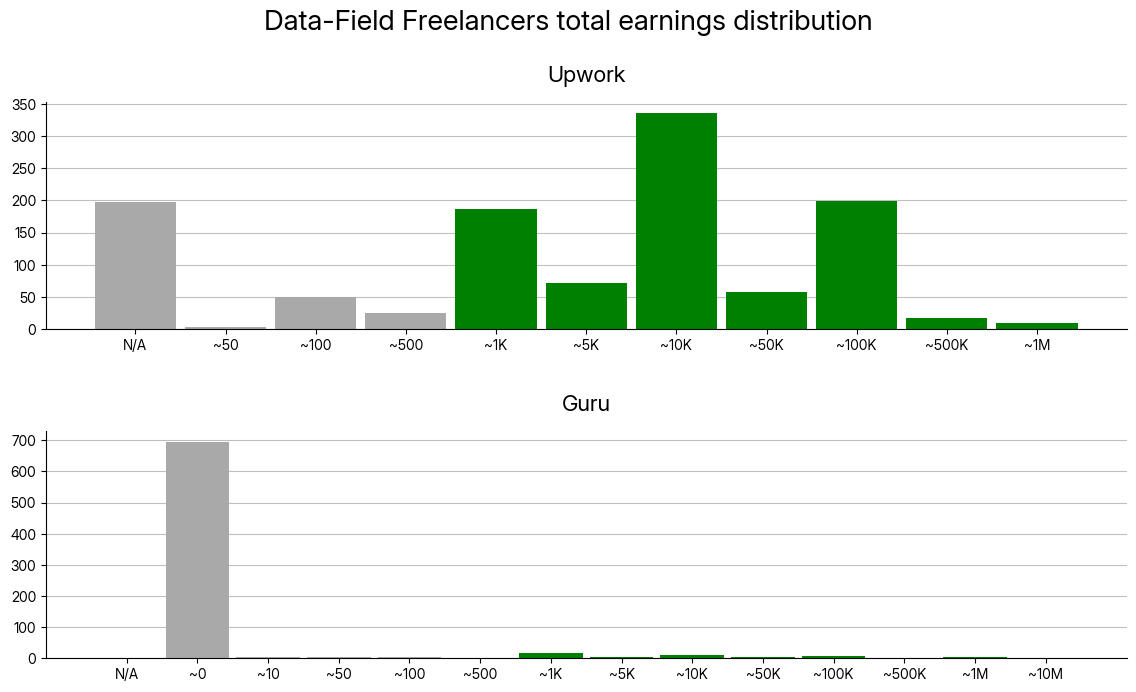

In [6]:
data = duckdb.sql(""" 
    SELECT COUNT(*) AS occurances,
    CASE
        WHEN earnings = 0 THEN 0
        WHEN earnings / POWER(10, FLOOR(LOG10(earnings+1))) BETWEEN 1 AND 4 THEN 1
        WHEN earnings / POWER(10, FLOOR(LOG10(earnings+1))) BETWEEN 4 AND 7 THEN 5
        ELSE 10
    END * POWER(10, FLOOR(LOG10(earnings+1))) AS earnings,
    platform
    FROM (
        SELECT id, earnings, 'upwork' AS platform FROM upwork_df
        UNION   
        SELECT url, earnings, 'guru' AS platform FROM guru_df
    )
    GROUP BY  CASE
        WHEN earnings = 0 THEN 0
        WHEN earnings / POWER(10, FLOOR(LOG10(earnings+1))) BETWEEN 1 AND 4 THEN 1
        WHEN earnings / POWER(10, FLOOR(LOG10(earnings+1))) BETWEEN 4 AND 7 THEN 5
        ELSE 10
    END * POWER(10, FLOOR(LOG10(earnings+1))), platform
    ORDER BY earnings
""").df()

def format_xticks(x):
    if np.isnan(x):    return "N/A"
    elif x < 1000:     return "~" + str(int(x))
    elif x < 1000_000: return "~" + str(int(x/1000)) + "K"
    else:              return "~" + str(int(x/1000_000)) + "M"

fig, axes = plt.subplots(2, 1)

for i, platform in enumerate(["upwork", "guru"]):
    sub_data = data[data["platform"] == platform]
    idx      = [-1] + [i for i in range(len(sub_data)) if i != -1]
    sub_data = sub_data.iloc[idx][:-1]
    
    positions = np.arange(len(sub_data))
    colors = (["green"] * len(sub_data))
    
    for j in range(len(positions)-1):
        if  np.isnan(sub_data["earnings"].iloc[j]) or + \
            sub_data["earnings"].iloc[j] < 1000:
            colors[j] = "darkgrey"
    
    axes[i].bar(positions, sub_data["occurances"], width= 0.9, color=colors)
    axes[i].set_xticks(positions, sub_data["earnings"].apply(format_xticks))
    
    axes[i].grid(True, axis='y', linestyle='-', linewidth=0.8, color='gray', alpha=0.5)
    axes[i].spines[['right', 'top']].set_visible(False)
    axes[i].set_axisbelow(True)
    
    axes[i].set_title(f"{platform.title()}", fontsize= 16, pad=15)

fig.set_size_inches(12, 7)
fig.tight_layout(pad=3.0)
fig.suptitle("Data-Field Freelancers total earnings distribution", fontsize=20, y = 1.02)

plt.show()

Oh, firstly we can confidently say that it's really really rare to earn any thing on Guru.<br>
There are only few people who acieved a lot but more than 95% of the people didn't earn<br>
anything, which means I will not be conducting further analysis to Guru's data.

Also we can see how common it is in UpWork to have earned some amount of freelancing<br>
though we can't be quite sure of how fast not easy was it to achieve those amounts but<br>
at least we can see decent earnings.<br>

So at least we can say that you can earn decent amounts on UpWork.

### Q2. Common skills <a id="q2"></a>

Now we should take a look at what are the essential skills freelancers need in thier profiles<br>
for each data-field job title.

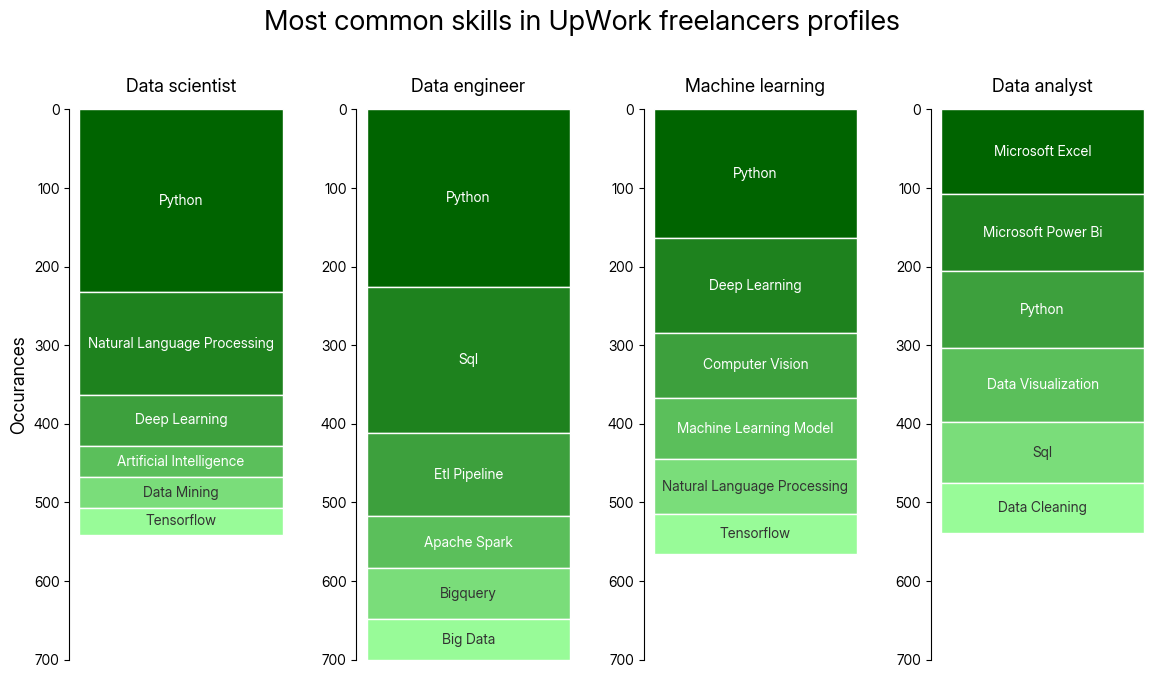

In [8]:
data = duckdb.sql("""
    SELECT * FROM (
        SELECT 
            skill, job_title,
            SUM(occurance) AS occurances, 
            ROW_NUMBER() OVER (PARTITION BY job_title ORDER BY occurances DESC) AS index
        FROM (
            SELECT 
                UNNEST(SPLIT(skills, ', ')) AS skill,
                searched_job_title AS job_title,
                1 AS occurance
            FROM upwork_df
        )
        WHERE skill <> 'Machine Learning' AND
            skill <> 'Data Analysis'      AND
            skill <> 'Data Engineering'   AND
            skill <> 'Data Science'
        GROUP BY skill, job_title
    )
    
    WHERE index <= 6
    ORDER BY occurances DESC
    """).df()

fig, axes = plt.subplots(nrows= 1, ncols=len(data["job_title"].unique()))

cmap = mpl.colors.LinearSegmentedColormap.from_list('custom', ["darkgreen", "PaleGreen"])

for ax, job_title in zip(axes, data["job_title"].unique()):
    bar_start = 0
    subdata = data[data["job_title"] == job_title]
    skills  = list(subdata["skill"].unique())
    # skills.reverse()
    colors  = list(cmap(np.linspace(1, 0, len(skills))))
    # colors.reverse()

    ax.spines[['right', 'top', 'bottom']].set_visible(False)
    ax.xaxis.set_ticks([])
    
    for i, skill in enumerate(skills):
        height = subdata[subdata["skill"] == skill]["occurances"].iloc[0]
        color = colors[(len(skills)-1) - i]
        r, g, b, _ = color
        text_color = "white" if (r * g * b) < 0.1 else "#333333"
        
        bar = ax.bar(x=1,
                height=height,
                bottom=bar_start,
                edgecolor="white",
                color=color
        )
        ax.set_title(f"{job_title}", fontsize=13, pad= 13)
        ax.bar_label(bar, label_type="center", labels=[skill.title()], color=text_color)
        ax.set_ylim(700, 0)
        # ax.set_ylim(sum(subdata["occurances"]), 0)

        bar_start += height

axes[0].set_ylabel("Occurances", fontsize=13)

fig.suptitle("Most common skills in UpWork freelancers profiles", fontsize=20)
fig.set_size_inches(12, 7)
fig.tight_layout(pad=2.0)
plt.show()

Intersting, Python is the most common skills among data-field freelancer's but we can also<br>
that "Data analyst" freelancers use Excel more often than Python *(with small difference)*.<br>

Also if you've read my jobs analysis notebook (Q4) you can see that Python is common here<br>
as it was there, but one notable difference is how ununiform skills are here.

### Q3. Hour rate change <a id="q3"></a>

Now let us take a look at the correlation between how many hours did the freelancer work<br>
and how much does he price his hour of work.<br>

**NOTE:** This might not be the most useful chart because of how many factors might play<br>
into this.

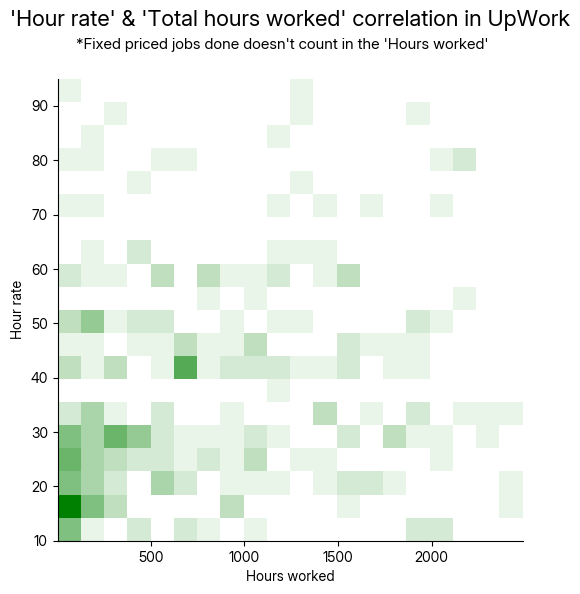

In [9]:
data = duckdb.sql("""
    SELECT hour_rate, hours_worked -- , searched_job_title
    FROM upwork_df
    WHERE hour_rate < 100 AND
        hours_worked < 2500 AND
        hourly_jobs_done > (fixed_jobs_done*2)/3
""").df()

fig, ax = plt.subplots()

cmap = mpl.colors.LinearSegmentedColormap.from_list('custom', ["white", "green"])

ax.hist2d(data["hours_worked"], data["hour_rate"], cmap=cmap, bins=20)
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel("Hour rate")
ax.set_xlabel("Hours worked")

ax.set_title("'Hour rate' & 'Total hours worked' correlation in UpWork", pad=38, fontsize=16)
plt.figtext(0.50, 0.93, "*Fixed priced jobs done doesn't count in the 'Hours worked'", ha="center", fontsize=11)

fig.set_size_inches(6, 6)

plt.show()

Now let's take a look at the [Pearson's correlation coffectient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) to
see the correlation in a <br>
mathmatical way<br>

And also we should take a look the the [P value](https://en.wikipedia.org/wiki/P-value) to see how signifcant is "Hours worked"

In [10]:
stat = scipy.stats.pearsonr(data['hour_rate'], data['hours_worked'])

print("correlation and sigficance between 'Hours worked' and 'Hour rate'\n\n" + \
     f"Pearson's r = {stat[0]}\n" + \
     f"P value     = {stat[1]}"
)

correlation and sigficance between 'Hours worked' and 'Hour rate'

Pearson's r = 0.1872526663408876
P value     = 0.001963174564893831


Simply this means that there's a positive relation between 'Hours worked' and 'Hour rate'<br>
and it's not just some random noise because $P < 0.05$ <br>
Though the correlation is not that strong.<br>

So now we can conclude that the more hours a freelancer has worked the more likely they<br>
are to increase thier pay rates<br>

### Q4. Average job cost <a id="q4"></a>

Finally I want to find how much does every job title of the freelancers earn per<br>
job done e.g *How much does a data scietist make per order (job) ?* .

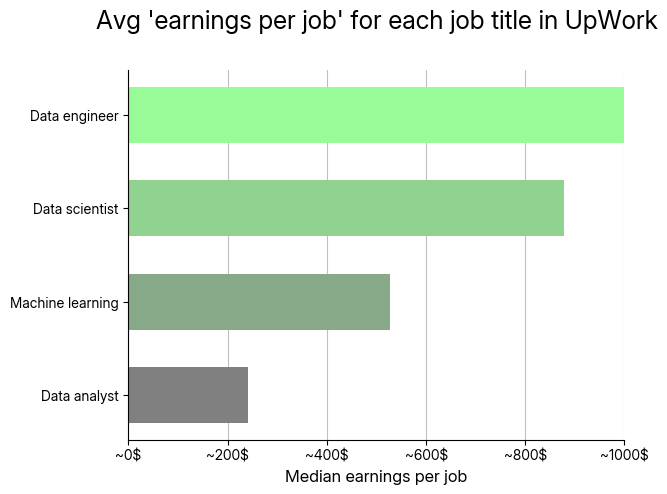

In [11]:
data = duckdb.sql("""
    SELECT 
        MEDIAN(earnings / (hourly_jobs_done + fixed_jobs_done)) AS avg_earnings_per_job,
        searched_job_title AS job_title
    FROM upwork_df
    GROUP BY searched_job_title
    ORDER BY avg_earnings_per_job
""").df()

fig, ax = plt.subplots()

# cmap   = mpl.colors.LinearSegmentedColormap.from_list('custom', ["#40ff40", "grey"])
cmap   = mpl.colors.LinearSegmentedColormap.from_list('custom', ["palegreen", "grey"])
colors = list(cmap(np.linspace(1, 0, len(data))))

ax.barh(y= data["job_title"], width=data["avg_earnings_per_job"],
        color=colors, height=0.6)

ax.set_xticks(ax.get_xticks(), pd.Series(ax.get_xticks()).apply(
    lambda x: "~" + str(round(x)) + "$"
))
ax.set_xlim(0, 1000)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True, axis='x', linestyle='-', linewidth=0.8, color='grey', alpha=0.5)
ax.set_axisbelow(True)

ax.set_xlabel("Median earnings per job", fontsize=12)
ax.set_title("Avg 'earnings per job' for each job title in UpWork", fontsize=18, pad=30)

plt.show()

I actually expected that data engineers will have the highest 'Earnings per job'.<br>
But what's surperising is that Machine learnings devs get half what the data<br>
engineers get per job but keep in mind that we don't know how much work do<br>
they (freelancers) do per job or how much time does it take.

# Summary

Thanks 💕 for looking into my humble analysis for the data-field analysis market<br>
hope you found it informative here's a summary of all of the findings:

**NOTE:** This summary was the only thing in the notebook written with an LLM

- [Q1](#q1). Earnings Distribution:<br>
Guru: Over 95% of freelancers earned nothing, indicating extremely low chances of<br>
success. Further analysis was discontinued for Guru.<br><br>
UpWork: Earnings are more common and generally decent, showing that freelancers<br>
can realistically achieve financial success on this platform (although the speed<br>
of earning is unknown).

- [Q2](#q2). Common Skills:<br>
Python is the most common skill among data-field freelancers overall.<br>
Excel slightly surpasses Python specifically for data analysts.<br>

- [Q3](#q3). Hourly Rate vs. Hours Worked<br>
There is a positive correlation between hours worked and hourly rate.<br>
The relationship is statistically significant but not very strong, meaning freelancers<br>
who work more hours tend to charge higher rates, but many other factors are also<br>
involved.

- [Q4](#q4). Average Earnings per Job<br>
Data engineers earn the highest amount per job.<br>
Machine learning freelancers earn about half as much per job as data engineers.<br>
time or effort per job is unknown, so earnings per job should not be interpreted as<br>
earnings per hour.